In [ ]:
import glob
import os
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

DATA_DIR = "data"
FX_DIR = f"{DATA_DIR}/fx"
MAX_LAG = 10
DAY = 0

def load_market_data(market: str) -> pd.DataFrame:
    """Load all CSV files for a given market ticker."""
    csv_files = glob.glob(f"./{FX_DIR}/{market}*.csv")
    dfs = []
    for csv_file in csv_files:
        df_temp = pd.read_csv(csv_file, header=0, skiprows=[1, 2], parse_dates=[0], index_col=0)
        df_temp.index.name = "Datetime"
        dfs.append(df_temp)
    data = pd.concat(dfs).sort_index()
    print(f"  {market}: {len(data)} rows")
    return data


def get_first_day(day_index: int, data: pd.DataFrame) -> pd.DataFrame:
    """Filter data to only the first day present."""
    days = data[data.index.weekday == day_index]
    first_date = days.index[0].normalize()
    return days[days.index.normalize() == first_date]


def is_stationary(series: pd.Series, alpha: float = 0.05) -> bool:
    """Return True if ADF test rejects unit root at given alpha."""
    result = adfuller(series.dropna(), autolag="AIC")
    return result[1] < alpha


def run_granger_pair(series_a: pd.Series, series_b: pd.Series, name_a: str, name_b: str, max_lag: int = MAX_LAG):
    """
    Run Granger causality in both directions for a pair.
    Returns dict with p-values and F-stats per lag per direction.
    """
    # First-difference both series to ensure stationarity
    diff_a = series_a.diff().dropna()
    diff_b = series_b.diff().dropna()

    aligned = pd.DataFrame({name_a: diff_a, name_b: diff_b}).dropna()
    if len(aligned) < max_lag + 5:
        return None  # Not enough data

    results = {}
    for direction, cols in [
        (f"{name_b}→{name_a}", [name_a, name_b]),  # does B Granger-cause A?
        (f"{name_a}→{name_b}", [name_b, name_a]),  # does A Granger-cause B?
    ]:
        gc = grangercausalitytests(aligned[cols], maxlag=max_lag, verbose=False)
        results[direction] = {
            "p_values": [gc[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1)],
            "f_stats": [gc[lag][0]["ssr_ftest"][0] for lag in range(1, max_lag + 1)],
        }
    return results


# Discover all FX markets from filenames
fx_files = sorted(glob.glob(f"./{FX_DIR}/*.csv"))
markets = sorted(set(os.path.basename(f).split("_")[0] for f in fx_files))
# Clean up ticker names for display (remove =X suffix)
market_labels = {m: m.replace("=X", "") for m in markets}

print(f"Found {len(markets)} FX markets: {[market_labels[m] for m in markets]}")
print(f"Total pairs: {len(markets) * (len(markets) - 1) // 2}")

Found 7 FX markets: ['AUDUSD', 'EURUSD', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']
Total pairs: 21


In [2]:
# Load all FX market data and extract first day
print("Loading all FX market data...")
all_data = {}
first_day_data = {}

for market in markets:
    raw = load_market_data(market)
    all_data[market] = raw
    first_day_data[market] = get_first_day(DAY, raw)

label = market_labels
print(f"\nFirst day data points per market:")
for m in markets:
    fm = first_day_data[m]
    print(f"  {label[m]}: {len(fm)} rows, date: {fm.index[0].date()}")

Loading all FX market data...
  AUDUSD=X: 4642 rows
  EURUSD=X: 9289 rows
  GBPUSD=X: 9288 rows
  NZDUSD=X: 4642 rows
  USDCAD=X: 9235 rows
  USDCHF=X: 9231 rows
  USDJPY=X: 9232 rows

First day data points per market:
  AUDUSD: 674 rows, date: 2026-02-20
  EURUSD: 1348 rows, date: 2026-02-20
  GBPUSD: 1348 rows, date: 2026-02-20
  NZDUSD: 674 rows, date: 2026-02-20
  USDCAD: 1324 rows, date: 2026-02-20
  USDCHF: 1320 rows, date: 2026-02-20
  USDJPY: 1320 rows, date: 2026-02-20


In [3]:
# Run Granger causality for all pairs
all_gc_results = {}
pair_list = list(combinations(markets, 2))

print(f"Running Granger causality for {len(pair_list)} pairs (max_lag={MAX_LAG})...\n")

for i, (m_a, m_b) in enumerate(pair_list, 1):
    la, lb = market_labels[m_a], market_labels[m_b]
    series_a = first_day_data[m_a]["Close"]
    series_b = first_day_data[m_b]["Close"]

    result = run_granger_pair(series_a, series_b, la, lb, MAX_LAG)
    if result is None:
        print(f"  [{i}/{len(pair_list)}] {la} <-> {lb}: SKIPPED (insufficient data)")
        continue

    all_gc_results[(la, lb)] = result

    # Report best lag (lowest p-value) for each direction
    for direction, vals in result.items():
        best_lag = np.argmin(vals["p_values"]) + 1
        best_p = min(vals["p_values"])
        sig = "SIG" if best_p < 0.05 else "   "
        print(f"  [{i}/{len(pair_list)}] {direction:<20} best lag={best_lag:>2}, p={best_p:.4f} {sig}")

print(f"\nCompleted {len(all_gc_results)} pairs.")

Running Granger causality for 21 pairs (max_lag=10)...

  [1/21] EURUSD→AUDUSD        best lag= 8, p=0.0519    
  [1/21] AUDUSD→EURUSD        best lag= 8, p=0.0007 SIG
  [2/21] GBPUSD→AUDUSD        best lag= 8, p=0.0237 SIG
  [2/21] AUDUSD→GBPUSD        best lag= 2, p=0.0000 SIG
  [3/21] NZDUSD→AUDUSD        best lag= 3, p=0.4310    
  [3/21] AUDUSD→NZDUSD        best lag= 7, p=0.0159 SIG


/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/fin

  [4/21] USDCAD→AUDUSD        best lag= 6, p=0.0000 SIG
  [4/21] AUDUSD→USDCAD        best lag= 6, p=0.0685    
  [5/21] USDCHF→AUDUSD        best lag= 5, p=0.0000 SIG
  [5/21] AUDUSD→USDCHF        best lag=10, p=0.0048 SIG


/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/fin

  [6/21] USDJPY→AUDUSD        best lag= 5, p=0.0012 SIG
  [6/21] AUDUSD→USDJPY        best lag= 9, p=0.0000 SIG
  [7/21] GBPUSD→EURUSD        best lag= 1, p=0.0013 SIG
  [7/21] EURUSD→GBPUSD        best lag= 4, p=0.0073 SIG
  [8/21] NZDUSD→EURUSD        best lag= 8, p=0.0000 SIG
  [8/21] EURUSD→NZDUSD        best lag= 8, p=0.0376 SIG


...

/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/fin

  [17/21] USDCHF→NZDUSD        best lag= 8, p=0.0000 SIG
  [17/21] NZDUSD→USDCHF        best lag= 7, p=0.0002 SIG
  [18/21] USDJPY→NZDUSD        best lag= 6, p=0.0000 SIG
  [18/21] NZDUSD→USDJPY        best lag= 9, p=0.0000 SIG
  [19/21] USDCHF→USDCAD        best lag= 5, p=0.0000 SIG
  [19/21] USDCAD→USDCHF        best lag= 4, p=0.0000 SIG


/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  [20/21] USDJPY→USDCAD        best lag= 3, p=0.2564    
  [20/21] USDCAD→USDJPY        best lag= 2, p=0.0001 SIG
  [21/21] USDJPY→USDCHF        best lag= 9, p=0.0038 SIG
  [21/21] USDCHF→USDJPY        best lag= 9, p=0.0000 SIG

Completed 21 pairs.


/home/unix/.pyenv/versions/finance/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


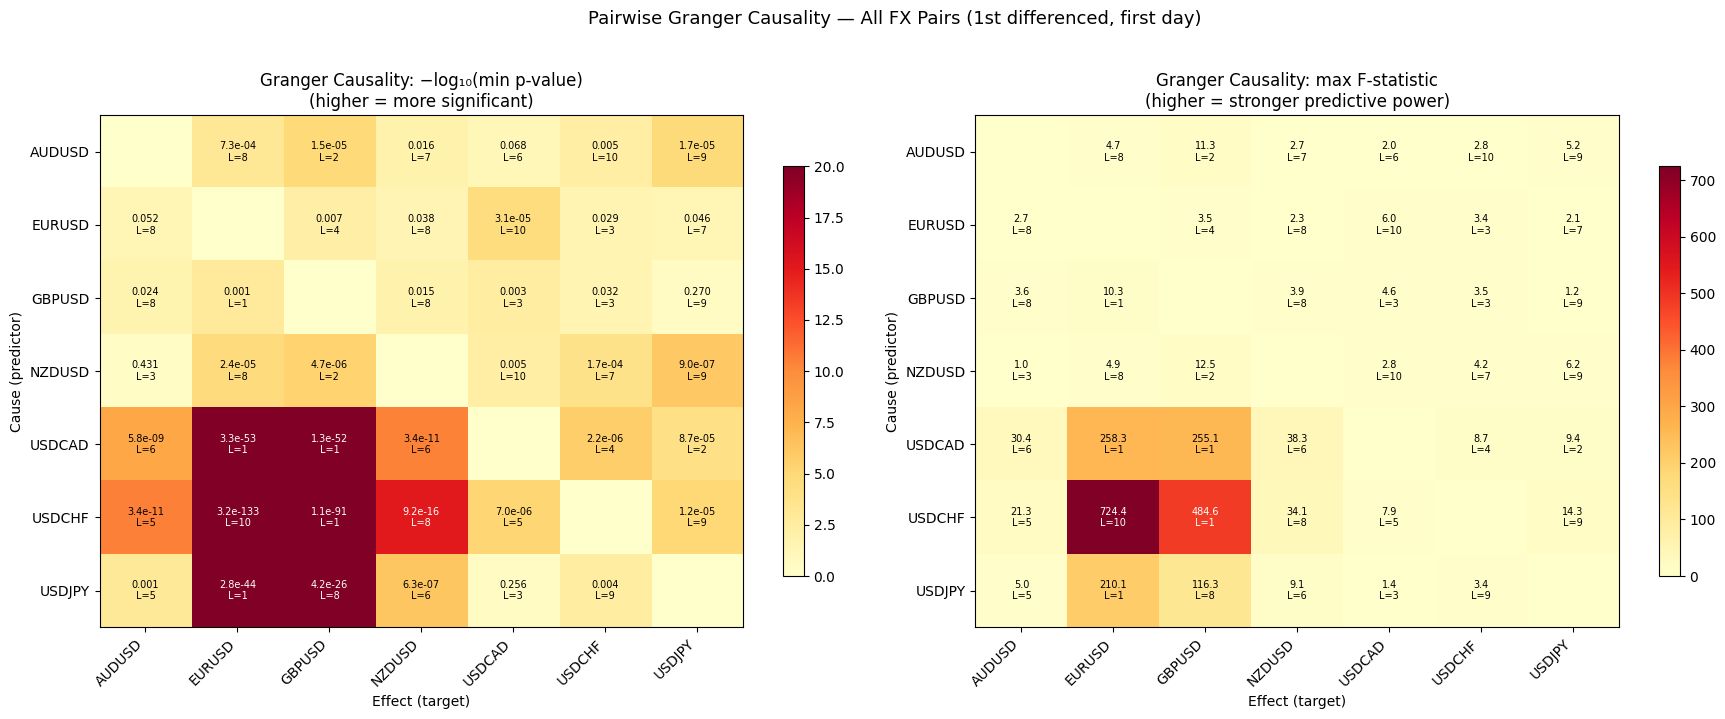


=== Significant Granger-causal relationships (p < 0.05 at best lag) ===
    USDCHF → EURUSD    p=0.0000  F=724.4  lag=10
    USDCHF → GBPUSD    p=0.0000  F=484.6  lag=1
    USDCAD → EURUSD    p=0.0000  F=258.3  lag=1
    USDCAD → GBPUSD    p=0.0000  F=255.1  lag=1
    USDJPY → EURUSD    p=0.0000  F=210.1  lag=1
    USDJPY → GBPUSD    p=0.0000  F=116.3  lag=8
    USDCHF → NZDUSD    p=0.0000  F=34.1  lag=8
    USDCHF → AUDUSD    p=0.0000  F=21.3  lag=5
    USDCAD → NZDUSD    p=0.0000  F=38.3  lag=6
    USDCAD → AUDUSD    p=0.0000  F=30.4  lag=6
    USDJPY → NZDUSD    p=0.0000  F=9.1  lag=6
    NZDUSD → USDJPY    p=0.0000  F=6.2  lag=9
    USDCAD → USDCHF    p=0.0000  F=8.7  lag=4
    NZDUSD → GBPUSD    p=0.0000  F=12.5  lag=2
    USDCHF → USDCAD    p=0.0000  F=7.9  lag=5
    USDCHF → USDJPY    p=0.0000  F=14.3  lag=9
    AUDUSD → GBPUSD    p=0.0000  F=11.3  lag=2
    AUDUSD → USDJPY    p=0.0000  F=5.2  lag=9
    NZDUSD → EURUSD    p=0.0000  F=4.9  lag=8
    EURUSD → USDCAD    p=0.0000  

In [5]:
# Build heatmap: minimum p-value across all lags for each directed pair
import matplotlib.colors as mcolors

labels = [market_labels[m] for m in markets]
n = len(labels)

# Matrix: row = cause, col = effect (row -> col)
p_matrix = np.ones((n, n))  # default 1.0 (no significance)
f_matrix = np.zeros((n, n))
lag_matrix = np.zeros((n, n), dtype=int)  # best lag for each pair

for (la, lb), result in all_gc_results.items():
    i_a = labels.index(la)
    i_b = labels.index(lb)
    for direction, vals in result.items():
        cause, effect = direction.split("→")
        i_cause = labels.index(cause)
        i_effect = labels.index(effect)
        p_matrix[i_cause, i_effect] = min(vals["p_values"])
        f_matrix[i_cause, i_effect] = max(vals["f_stats"])
        lag_matrix[i_cause, i_effect] = np.argmin(vals["p_values"]) + 1

# --- Heatmap 1: p-values (log scale, lower = more significant) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Use -log10(p) for better visual separation
neg_log_p = -np.log10(np.clip(p_matrix, 1e-20, 1.0))
np.fill_diagonal(neg_log_p, 0)

im1 = axes[0].imshow(neg_log_p, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks(range(n))
axes[0].set_xticklabels(labels, rotation=45, ha="right")
axes[0].set_yticks(range(n))
axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Effect (target)")
axes[0].set_ylabel("Cause (predictor)")
axes[0].set_title("Granger Causality: −log₁₀(min p-value)\n(higher = more significant)")
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# Annotate with actual p-values and best lag
for i in range(n):
    for j in range(n):
        if i != j:
            p = p_matrix[i, j]
            lag = lag_matrix[i, j]
            txt_p = f"{p:.3f}" if p >= 0.001 else f"{p:.1e}"
            txt = f"{txt_p}\nL={lag}"
            color = "white" if neg_log_p[i, j] > neg_log_p.max() * 0.6 else "black"
            axes[0].text(j, i, txt, ha="center", va="center", fontsize=7, color=color)

# Add significance threshold line in colorbar
threshold_line = -np.log10(0.05)
axes[0].axhline(y=-0.5, color='none')  # dummy

# --- Heatmap 2: max F-statistic ---
np.fill_diagonal(f_matrix, 0)
im2 = axes[1].imshow(f_matrix, cmap="YlOrRd", aspect="auto")
axes[1].set_xticks(range(n))
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Effect (target)")
axes[1].set_ylabel("Cause (predictor)")
axes[1].set_title("Granger Causality: max F-statistic\n(higher = stronger predictive power)")
plt.colorbar(im2, ax=axes[1], shrink=0.8)

for i in range(n):
    for j in range(n):
        if i != j:
            f = f_matrix[i, j]
            lag = lag_matrix[i, j]
            txt = f"{f:.1f}\nL={lag}"
            color = "white" if f > f_matrix.max() * 0.6 else "black"
            axes[1].text(j, i, txt, ha="center", va="center", fontsize=7, color=color)

plt.suptitle("Pairwise Granger Causality — All FX Pairs (1st differenced, first day)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print significant pairs
print("\n=== Significant Granger-causal relationships (p < 0.05 at best lag) ===")
sig_pairs = []
for i in range(n):
    for j in range(n):
        if i != j and p_matrix[i, j] < 0.05:
            sig_pairs.append((labels[i], labels[j], p_matrix[i, j], f_matrix[i, j], lag_matrix[i, j]))

sig_pairs.sort(key=lambda x: x[2])
for cause, effect, p, f, lag in sig_pairs:
    print(f"  {cause:>8} → {effect:<8}  p={p:.4f}  F={f:.1f}  lag={lag}")